In [1]:
from quickdraw import QuickDrawDataGroup
import numpy as np
import random
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [2]:
with open('../../data/categories/sports.txt') as f:
    CATEGORIES = [c.strip() for c in f.read().split(',')]
print(CATEGORIES)

['baseball', 'baseball bat', 'basketball', 'bicycle', 'canoe', 'dumbbell', 'diving board', 'golf club', 'hockey puck', 'hockey stick', 'rollerskates', 'skateboard', 'soccer ball', 'tennis racquet', 'yoga']


In [3]:
SAMPLES = 3000
IMG_SIZE = 128
images = []
labels = []
for cat in CATEGORIES:
    group = QuickDrawDataGroup(cat, max_drawings=SAMPLES)
    for drawing in group.drawings:
        img = np.array(drawing.image.convert('L').resize((IMG_SIZE, IMG_SIZE)))
        images.append(img)
        labels.append(cat)

loading baseball drawings
load complete
loading baseball bat drawings
load complete
loading basketball drawings
load complete
loading bicycle drawings
load complete
loading canoe drawings
load complete
loading dumbbell drawings
load complete
loading diving board drawings
load complete
loading golf club drawings
load complete
loading hockey puck drawings
load complete
loading hockey stick drawings
load complete
loading rollerskates drawings
load complete
loading skateboard drawings
load complete
loading soccer ball drawings
load complete
loading tennis racquet drawings
load complete
loading yoga drawings
load complete


In [4]:
label_map = {cat: i for i, cat in enumerate(CATEGORIES)}

X = np.array(images) / 255.0 
y = np.array([label_map[l] for l in labels])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (36000, 128, 128), Test: (9000, 128, 128)


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sportscnn import SportsCNN

X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.long)

num_classes = len(CATEGORIES)
EMBEDDING_DIM = 128

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)


In [6]:
model = SportsCNN(num_classes=num_classes, img_size=IMG_SIZE, embedding_dim=EMBEDDING_DIM)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss() 

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
model.to(device)


Using device: mps


SportsCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (embed): Linear(in_features=32768, out_features=128, bias=True)
  (fc): Linear(in_features=128, out_features=15, bias=True)
)

In [7]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    train_loss = total_loss / len(train_loader.dataset)

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x_eval, y_eval in test_loader:
            x_eval, y_eval = x_eval.to(device), y_eval.to(device)
            preds = model(x_eval).argmax(dim=1)
            correct += (preds == y_eval).sum().item()
            total += y_eval.size(0)

    test_acc = correct / total
    print(f"Epoch: {epoch+1} | loss: {train_loss:.4f} | acc: {test_acc:.4f}")


Epoch: 1 | loss: 1.2926 | acc: 0.7171
Epoch: 2 | loss: 0.7753 | acc: 0.7461
Epoch: 3 | loss: 0.5913 | acc: 0.7301
Epoch: 4 | loss: 0.4384 | acc: 0.7267
Epoch: 5 | loss: 0.3003 | acc: 0.7216
Epoch: 6 | loss: 0.1936 | acc: 0.7056
Epoch: 7 | loss: 0.1216 | acc: 0.7040
Epoch: 8 | loss: 0.0854 | acc: 0.7043
Epoch: 9 | loss: 0.0646 | acc: 0.7024
Epoch: 10 | loss: 0.0596 | acc: 0.7048


In [8]:
# Save trained model weights to .pth file
torch.save(model.state_dict(), "sports_simplecnn.pth")
print("Saved model weights to sports_simplecnn.pth")


Saved model weights to sports_simplecnn.pth


                precision    recall  f1-score   support

      baseball       0.60      0.63      0.62       600
  baseball bat       0.76      0.80      0.78       600
    basketball       0.57      0.49      0.53       600
       bicycle       0.80      0.85      0.82       600
         canoe       0.81      0.85      0.83       600
      dumbbell       0.75      0.77      0.76       600
  diving board       0.71      0.63      0.67       600
     golf club       0.59      0.61      0.60       600
   hockey puck       0.66      0.68      0.67       600
  hockey stick       0.63      0.52      0.57       600
  rollerskates       0.83      0.80      0.81       600
    skateboard       0.76      0.86      0.80       600
   soccer ball       0.63      0.65      0.64       600
tennis racquet       0.76      0.87      0.81       600
          yoga       0.64      0.56      0.60       600

      accuracy                           0.70      9000
     macro avg       0.70      0.70      0.70 

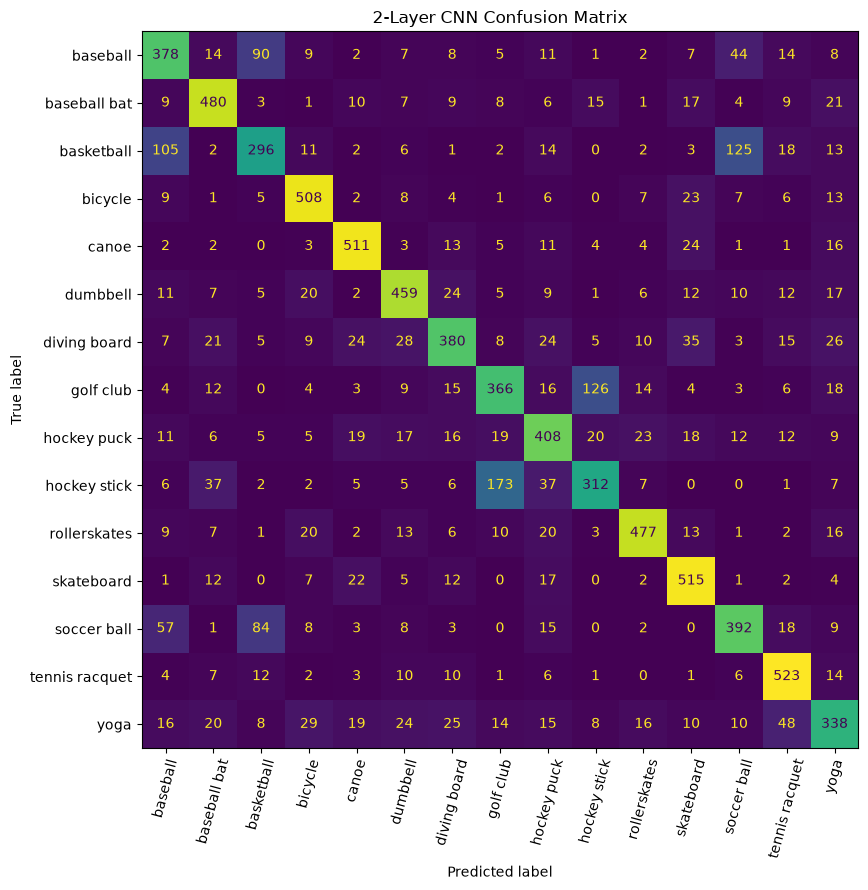

In [9]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x_eval, y_eval in test_loader:
        x_eval, y_eval = x_eval.to(device), y_eval.to(device)
        batch_preds = model(x_eval).argmax(dim=1)
        all_preds.append(batch_preds.cpu())
        all_labels.append(y_eval.cpu())

preds = torch.cat(all_preds).numpy()
y_test_final = torch.cat(all_labels).numpy()

print(classification_report(y_test_final, preds, target_names=CATEGORIES, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test_final, preds, display_labels=CATEGORIES, xticks_rotation=75, ax=ax, colorbar=False
)
plt.title("2-Layer CNN Confusion Matrix")
plt.tight_layout()
plt.show()


In [10]:
from sklearn.cluster import KMeans

model.eval()

X_all_t = torch.tensor(X, dtype=torch.float32).unsqueeze(1) 
y_all = y 

all_embeddings = []
batch_size = 64

with torch.no_grad():
    for i in range(0, len(X_all_t), batch_size):
        batch = X_all_t[i:i+batch_size].to(device)
        _, emb = model(batch, return_embedding=True)
        all_embeddings.append(emb.cpu().numpy())

all_embeddings = np.concatenate(all_embeddings, axis=0)
print(f"Extracted embeddings shape: {all_embeddings.shape}")

Extracted embeddings shape: (45000, 128)


In [11]:
K_VALUES = [1, 5, 10]

# centroids[k] will be shape (num_classes, k, EMBEDDING_DIM)
centroids = {k: np.zeros((num_classes, k, EMBEDDING_DIM)) for k in K_VALUES}

for class_idx, cat in enumerate(CATEGORIES):
    class_mask = (y_all == class_idx)
    class_embeddings = all_embeddings[class_mask]  # (n_samples_this_class, EMBEDDING_DIM)

    for k in K_VALUES:
        if k == 1:
            # single centroid = mean of all embeddings for this class
            centroids[1][class_idx, 0] = class_embeddings.mean(axis=0)
        else:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans.fit(class_embeddings)
            centroids[k][class_idx] = kmeans.cluster_centers_

    print(f"{cat}: {class_embeddings.shape[0]} samples -> centroids computed for k={K_VALUES}")

baseball: 3000 samples -> centroids computed for k=[1, 5, 10]
baseball bat: 3000 samples -> centroids computed for k=[1, 5, 10]
basketball: 3000 samples -> centroids computed for k=[1, 5, 10]
bicycle: 3000 samples -> centroids computed for k=[1, 5, 10]
canoe: 3000 samples -> centroids computed for k=[1, 5, 10]
dumbbell: 3000 samples -> centroids computed for k=[1, 5, 10]
diving board: 3000 samples -> centroids computed for k=[1, 5, 10]
golf club: 3000 samples -> centroids computed for k=[1, 5, 10]
hockey puck: 3000 samples -> centroids computed for k=[1, 5, 10]
hockey stick: 3000 samples -> centroids computed for k=[1, 5, 10]
rollerskates: 3000 samples -> centroids computed for k=[1, 5, 10]
skateboard: 3000 samples -> centroids computed for k=[1, 5, 10]
soccer ball: 3000 samples -> centroids computed for k=[1, 5, 10]
tennis racquet: 3000 samples -> centroids computed for k=[1, 5, 10]
yoga: 3000 samples -> centroids computed for k=[1, 5, 10]


In [12]:
from pathlib import Path

OUTPUT_DIR = Path("../../data/centroids")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for k in K_VALUES:
    fname = OUTPUT_DIR / f"sports_{k}.npz"
    np.savez(fname, centroids=centroids[k], categories=np.array(CATEGORIES))
    print(f"Saved {fname}, shape={centroids[k].shape}")


Saved ../../data/centroids/sports_1.npz, shape=(15, 1, 128)
Saved ../../data/centroids/sports_5.npz, shape=(15, 5, 128)
Saved ../../data/centroids/sports_10.npz, shape=(15, 10, 128)


In [13]:
from PIL import Image
from pathlib import Path

OUTPUT_DIR = Path("../../data/centroids")
K_VALUES = [1, 5, 10]

centroids = {}
for k in K_VALUES:
    data = np.load(OUTPUT_DIR / f"sports_{k}.npz", allow_pickle=True)
    centroids[k] = data["centroids"]
    saved_categories = data["categories"]
    assert list(saved_categories) == CATEGORIES, "Category order mismatch between saved centroids and current CATEGORIES!"

DRAWINGS_DIR = Path("../../data/base_drawings/sports")
EVAL_CATEGORIES = CATEGORIES  # evaluate all 15 subcategories

eval_images = []
eval_labels = []
eval_quality = []

for cat in EVAL_CATEGORIES:
    for quality in ["good", "bad"]:
        fname = f"{cat.replace(' ', '_')}_{quality}.png"
        path = DRAWINGS_DIR / fname
        if not path.exists():
            print(f"MISSING: {path}")
            continue
        img = np.array(Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE)))
        eval_images.append(img)
        eval_labels.append(cat)
        eval_quality.append(quality)

print(f"Loaded {len(eval_images)} eval drawings")


Loaded 30 eval drawings


In [14]:
eval_X = np.array(eval_images) / 255.0
eval_X_t = torch.tensor(eval_X, dtype=torch.float32).unsqueeze(1).to(device)

model.eval()
with torch.no_grad():
    _, eval_embeddings = model(eval_X_t, return_embedding=True)
eval_embeddings = eval_embeddings.cpu().numpy()  # (30, EMBEDDING_DIM)

print(f"Eval embeddings shape: {eval_embeddings.shape}")

Eval embeddings shape: (30, 128)


In [15]:
from sklearn.metrics.pairwise import cosine_similarity

results = {"good": pd.DataFrame(index=K_VALUES, columns=EVAL_CATEGORIES, dtype=float),
           "bad":  pd.DataFrame(index=K_VALUES, columns=EVAL_CATEGORIES, dtype=float)}

for i, (cat, quality) in enumerate(zip(eval_labels, eval_quality)):
    class_idx = CATEGORIES.index(cat)  # still index into full CATEGORIES, since centroids array covers all 15
    emb = eval_embeddings[i].reshape(1, -1)

    for k in K_VALUES:
        class_centroids = centroids[k][class_idx]
        sims = cosine_similarity(emb, class_centroids)
        avg_sim = sims.mean()
        results[quality].loc[k, cat] = avg_sim

In [16]:
print("=== GOOD drawings: avg cosine similarity to own-class centroids ===")
display(results["good"].round(3))

print("\n=== BAD drawings: avg cosine similarity to own-class centroids ===")
display(results["bad"].round(3))

=== GOOD drawings: avg cosine similarity to own-class centroids ===


,baseball,baseball bat,basketball,bicycle,canoe,dumbbell,diving board,golf club,hockey puck,hockey stick,rollerskates,skateboard,soccer ball,tennis racquet,yoga
1,0.797,0.330,0.781,0.534,0.436,0.467,0.504,0.515,0.499,0.742,0.673,0.264,0.861,0.576,0.723
5,0.739,0.265,0.735,0.521,0.458,0.463,0.490,0.450,0.514,0.649,0.583,0.260,0.830,0.547,0.641
10,0.728,0.256,0.717,0.488,0.434,0.448,0.482,0.457,0.514,0.630,0.602,0.241,0.806,0.523,0.636



=== BAD drawings: avg cosine similarity to own-class centroids ===


,baseball,baseball bat,basketball,bicycle,canoe,dumbbell,diving board,golf club,hockey puck,hockey stick,rollerskates,skateboard,soccer ball,tennis racquet,yoga
1,0.755,0.540,0.744,0.627,0.378,0.489,0.294,0.518,0.418,0.664,0.322,0.238,0.689,0.239,0.380
5,0.696,0.444,0.693,0.577,0.360,0.476,0.293,0.443,0.415,0.582,0.286,0.233,0.669,0.234,0.339
10,0.687,0.432,0.684,0.551,0.357,0.466,0.282,0.448,0.412,0.563,0.290,0.218,0.651,0.218,0.341


In [17]:
eval_drawing_names = [f"{cat} ({quality})" for cat, quality in zip(eval_labels, eval_quality)]

# Cosine Similarity Matrix (30 drawings x 15 categories, k=1 centroid)
matrix_30x15 = pd.DataFrame(index=eval_drawing_names, columns=CATEGORIES, dtype=float)

for i, drawing_name in enumerate(eval_drawing_names):
    emb = eval_embeddings[i].reshape(1, -1)
    for j, cat_name in enumerate(CATEGORIES):
        class_centroid = centroids[1][j]  # (1, EMBEDDING_DIM)
        sim = cosine_similarity(emb, class_centroid)[0, 0]
        matrix_30x15.loc[drawing_name, cat_name] = round(float(sim), 4)

print("=== 30x15 Cosine Similarity Matrix (30 Drawings vs 15 Classes, k=1 Centroid) ===")
display(matrix_30x15)


=== 30x15 Cosine Similarity Matrix (30 Drawings vs 15 Classes, k=1 Centroid) ===


,baseball,baseball bat,basketball,bicycle,canoe,dumbbell,diving board,golf club,hockey puck,hockey stick,rollerskates,skateboard,soccer ball,tennis racquet,yoga
baseball (good),0.7968,0.3539,0.7908,0.4129,0.2242,0.4364,0.4209,0.3591,0.5048,0.4063,0.4517,0.3020,0.8105,0.4080,0.5777
baseball (bad),0.7553,0.3281,0.7519,0.3858,0.2477,0.4200,0.4304,0.2841,0.4976,0.3558,0.4439,0.2934,0.7859,0.3412,0.5364
baseball bat (good),0.3440,0.3297,0.2706,0.1723,0.2042,0.2482,0.2896,0.3389,0.4058,0.4410,0.2004,0.3574,0.3657,0.2178,0.3107
baseball bat (bad),0.4400,0.5403,0.3350,0.2894,0.2507,0.3476,0.3413,0.5891,0.4347,0.7030,0.4076,0.3251,0.3973,0.2721,0.4776
basketball (good),0.6620,0.2444,0.7815,0.4846,0.2264,0.3121,0.3755,0.1981,0.5282,0.2329,0.4097,0.2792,0.7464,0.3402,0.4622
basketball (bad),0.7318,0.2498,0.7443,0.3413,0.2583,0.3113,0.3540,0.3814,0.4475,0.4423,0.4291,0.2681,0.6584,0.2636,0.4584
bicycle (good),0.3754,0.4521,0.4110,0.5344,0.1388,0.3821,0.4187,0.5039,0.4710,0.4604,0.7459,0.2563,0.4585,0.3816,0.5329
bicycle (bad),0.5640,0.5339,0.5433,0.6271,0.2979,0.4688,0.5128,0.4974,0.4971,0.5006,0.5859,0.3868,0.5503,0.4671,0.6738
canoe (good),0.4124,0.2945,0.4373,0.3644,0.4365,0.3254,0.4061,0.3431,0.5886,0.4595,0.4063,0.4712,0.4950,0.2872,0.4753
canoe (bad),0.3647,0.3640,0.3533,0.2207,0.3776,0.2923,0.3268,0.2583,0.5166,0.3529,0.2591,0.3568,0.3963,0.4362,0.3106


## Interactive Gradio ImageEditor

In [18]:
import gradio as gr
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity

def predict_drawing(editor_value):
    if editor_value is None:
        return pd.DataFrame()
    
    # Extract composite image from ImageEditor dictionary or PIL Image
    if isinstance(editor_value, dict):
        img = editor_value.get("composite", None)
    else:
        img = editor_value

    if img is None:
        return pd.DataFrame()

    # Handle transparency by compositing onto a solid white background
    if img.mode in ("RGBA", "LA") or (img.mode == "P" and "transparency" in img.info):
        bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
        img = Image.alpha_composite(bg, img.convert("RGBA")).convert("RGB")

    # Preprocess drawing matching QuickDraw format (grayscale, 128x128, [0, 1])
    img = img.convert("L").resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img, dtype=np.float32) / 255.0

    # Convert to tensor: shape (1, 1, IMG_SIZE, IMG_SIZE)
    input_tensor = torch.tensor(img_array, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    # Extract CNN embedding
    model.eval()
    with torch.no_grad():
        _, query_embedding = model(input_tensor, return_embedding=True)
    query_embedding = query_embedding.cpu().numpy()  # (1, EMBEDDING_DIM)

    # Compute cosine similarity against all categories for k in [1, 5, 10]
    results = []
    for class_idx, cat in enumerate(CATEGORIES):
        row = {"Category": cat}
        for k in K_VALUES:
            class_centroids = centroids[k][class_idx]  # shape: (k, EMBEDDING_DIM)
            sims = cosine_similarity(query_embedding, class_centroids)
            row[f"k={k} Avg Sim"] = round(float(sims.mean()), 4)
            if k > 1:
                row[f"k={k} Max Sim"] = round(float(sims.max()), 4)
        results.append(row)

    report = pd.DataFrame(results)
    # Sort descending by 1-centroid similarity
    report = report.sort_values(by="k=1 Avg Sim", ascending=False).reset_index(drop=True)
    return report

demo = gr.Interface(
    fn=predict_drawing,
    inputs=gr.ImageEditor(type="pil", label="Draw a sports item"),
    outputs=gr.Dataframe(label="Cosine Similarity by Category"),
    title="Sports QuickDraw - Category Cosine Similarity",
    description="Draw a sports-related item and see its cosine similarity across all categories and centroid configurations."
)

demo.launch()


/Users/dylanlouie/Projects/su26-ai-team-3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
